# Spatial Analysis of PM Pollution in Nairobi

This notebook visualizes the spatial distribution of PM pollution
across Nairobi and identifies potential pollution hotspots.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import folium
from folium.plugins import HeatMap
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/air_quality/Outputs/clean_spatial_pm.csv")
df.head()


,sensor_id,lat,lon,mean_pm
0,3,-1.311,36.767,4.890583
1,3,-1.288,36.841,18.123454
2,3,-1.259,36.799,847.404735
3,21,-1.292,36.821,10.243000
4,23,-1.298,36.791,16.374026


## Converting PM Data to Spatial Format


Creating a Geodataframe

In [ ]:
geometry = [Point(xy) for xy in zip(df["lon"], df["lat"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

Static Map

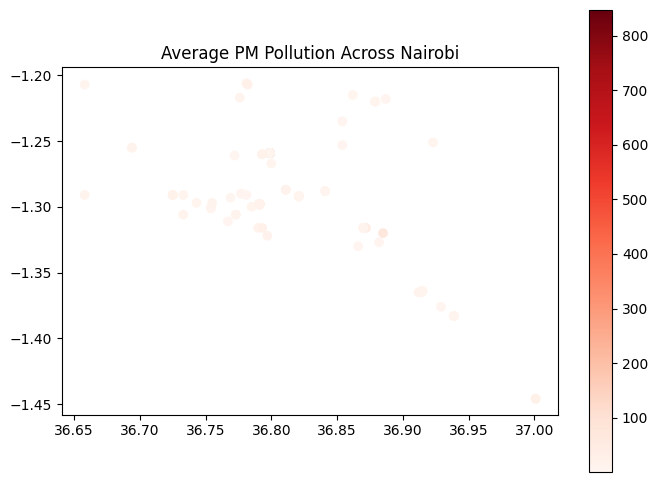

In [ ]:
gdf.plot(column="mean_pm", cmap="Reds", legend=True, figsize=(8,6))
plt.title("Average PM Pollution Across Nairobi")
plt.show()

Heat Map

In [ ]:
map_nairobi = folium.Map(location=[-1.2921, 36.8219], zoom_start=11)
heat_data = [[row.lat, row.lon, row.mean_pm] for _, row in df.iterrows()]
HeatMap(heat_data).add_to(map_nairobi)
map_nairobi